Вам предстоит решить задачу классификации сложных цветных изображений — датасет **CIFAR-10**.
В нем 10 классов: самолеты, автомобили, птицы, кошки, олени, собаки, лягушки, лошади, корабли, грузовики.

**Ваша цель:** Пробить "потолок" точности (`accuracy`) в **50%** на тестовой выборке.
**Главное правило:** Запрещено использовать любые слои, кроме `Dense`, `Dropout`, `Input` и слоев регуляризации. Никаких сверточных нейросетей (CNN)! Только полносвязные сети.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks

def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    ax1.plot(history.history['loss'], label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Validation Loss')
    ax1.set_title(f'{title} - Loss')
    ax1.legend()

    ax2.plot(history.history['accuracy'], label='Train Accuracy')
    ax2.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax2.set_title(f'{title} - Accuracy')
    ax2.legend()

    plt.show()

### Шаг 1: Загрузка и подготовка данных
Изображения цветные, размер 32x32 пикселя, 3 канала (RGB).
1. Загрузите датасет CIFAR-10.
2. "Распрямите" изображения (Flatten) в плоский вектор. Какова будет его размерность?
3. Масштабируйте данные (от 0 до 1).
4. Закодируйте метки классов (y) методом One-Hot Encoding.

In [4]:
# Загрузка данных
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train = X_train.reshape(len(X_train), -1)
X_test = X_test.reshape(len(X_test), -1)

y_train = keras.utils.to_categorical(y_train.reshape(-1), 10)
y_test = keras.utils.to_categorical(y_test.reshape(-1), 10)

print("Размер одного изображения после Flatten:", X_train.shape[1])
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("Диапазон пикселей:", X_train.min(), X_train.max())

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1580s 9us/step
Размер одного изображения после Flatten: 3072
X_train: (50000, 3072)
y_train: (50000, 10)
Диапазон пикселей: 0.0 1.0


### Шаг 2: Модель "Слабое звено" (Недообучение)
Давайте посмотрим, что будет, если дать сложной задаче слишком простую модель.
1. Создайте сеть всего с одним скрытым слоем на **32 нейрона** (активация `relu`).
2. Добавьте выходной слой. *Внимание! Подумайте, какая функция активации и loss-функция нужны для 10 классов.*
3. Обучите на 15 эпохах.
4. Постройте графики. Сделайте выводы: хватает ли емкости этой сети, чтобы уловить закономерности в цветных фото?

Epoch 1/15
352/352 - 3s - 8ms/step - accuracy: 0.2762 - loss: 1.9942 - val_accuracy: 0.3070 - val_loss: 1.9045
Epoch 2/15
352/352 - 2s - 5ms/step - accuracy: 0.3306 - loss: 1.8612 - val_accuracy: 0.3364 - val_loss: 1.8542
Epoch 3/15
352/352 - 2s - 7ms/step - accuracy: 0.3523 - loss: 1.8178 - val_accuracy: 0.3384 - val_loss: 1.8362
Epoch 4/15
352/352 - 2s - 5ms/step - accuracy: 0.3652 - loss: 1.7883 - val_accuracy: 0.3522 - val_loss: 1.8060
Epoch 5/15
352/352 - 3s - 7ms/step - accuracy: 0.3709 - loss: 1.7724 - val_accuracy: 0.3554 - val_loss: 1.7904
Epoch 6/15
352/352 - 2s - 5ms/step - accuracy: 0.3743 - loss: 1.7643 - val_accuracy: 0.3538 - val_loss: 1.7958
Epoch 7/15
352/352 - 2s - 7ms/step - accuracy: 0.3786 - loss: 1.7522 - val_accuracy: 0.3658 - val_loss: 1.7691
Epoch 8/15
352/352 - 2s - 5ms/step - accuracy: 0.3829 - loss: 1.7427 - val_accuracy: 0.3724 - val_loss: 1.7521
Epoch 9/15
352/352 - 3s - 7ms/step - accuracy: 0.3841 - loss: 1.7342 - val_accuracy: 0.3786 - val_loss: 1.7464
E

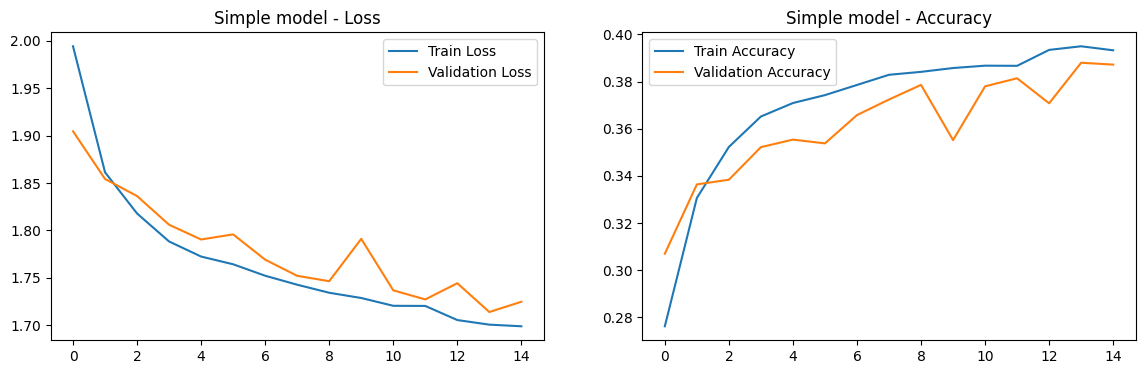

Test accuracy: 0.38190001249313354


In [6]:
simple_model = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(10, activation="softmax")
])

simple_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

simple_history = simple_model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=128,
    verbose=2
)

plot_history(simple_history, "Simple model")
simple_loss, simple_accuracy = simple_model.evaluate(X_test, y_test, verbose=0)
print("Test accuracy:", simple_accuracy)

### Шаг 3: Модель "Зубрила" (Переобучение)
Простая модель не справилась (метрики застряли на ~30%). Дадим сети больше мощности!
1. Постройте глубокую полносвязную сеть (например, скрытые слои на **1024, 512 и 256 нейронов**).
2. **Не используйте** Dropout или регуляризацию.
3. Обучите на 25 эпохах.
4. Постройте графики. **Вопрос для размышления:** На какой эпохе сеть перестала учиться обобщать и начала просто "зазубривать" тренировочные данные? Как вы это поняли по графику Loss?

Epoch 1/25
352/352 - 22s - 63ms/step - accuracy: 0.3090 - loss: 1.9223 - val_accuracy: 0.3636 - val_loss: 1.7629
Epoch 2/25
352/352 - 21s - 60ms/step - accuracy: 0.3900 - loss: 1.6993 - val_accuracy: 0.4162 - val_loss: 1.6348
Epoch 3/25
352/352 - 21s - 61ms/step - accuracy: 0.4271 - loss: 1.6003 - val_accuracy: 0.4380 - val_loss: 1.5738
Epoch 4/25
352/352 - 22s - 61ms/step - accuracy: 0.4530 - loss: 1.5357 - val_accuracy: 0.4560 - val_loss: 1.5177
Epoch 5/25
352/352 - 40s - 114ms/step - accuracy: 0.4686 - loss: 1.4873 - val_accuracy: 0.4520 - val_loss: 1.5164
Epoch 6/25
352/352 - 21s - 60ms/step - accuracy: 0.4838 - loss: 1.4493 - val_accuracy: 0.4870 - val_loss: 1.4534
Epoch 7/25
352/352 - 21s - 61ms/step - accuracy: 0.4977 - loss: 1.4073 - val_accuracy: 0.4798 - val_loss: 1.4491
Epoch 8/25
352/352 - 41s - 117ms/step - accuracy: 0.5062 - loss: 1.3814 - val_accuracy: 0.4856 - val_loss: 1.4497
Epoch 9/25
352/352 - 22s - 61ms/step - accuracy: 0.5156 - loss: 1.3509 - val_accuracy: 0.4812 

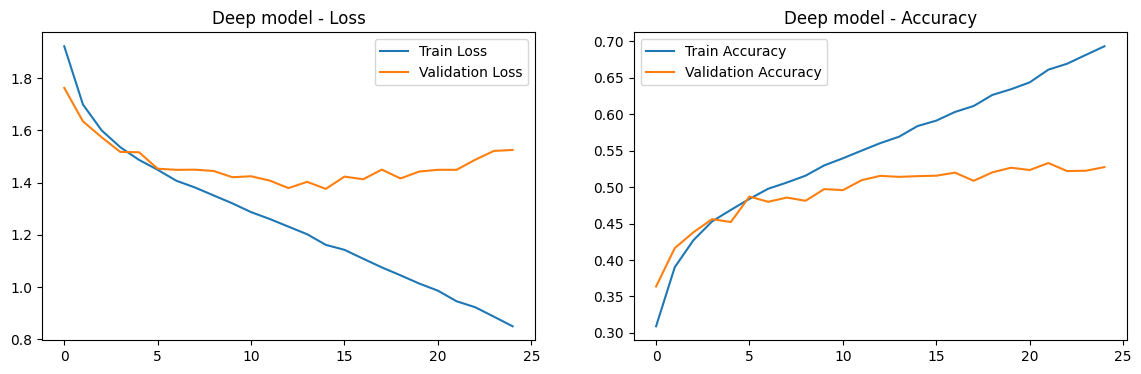

Test accuracy: 0.5205000042915344


In [7]:
deep_model = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(1024, activation="relu"),
    layers.Dense(512, activation="relu"),
    layers.Dense(256, activation="relu"),
    layers.Dense(10, activation="softmax")
])

deep_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

deep_history = deep_model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=25,
    batch_size=128,
    verbose=2
)

plot_history(deep_history, "Deep model")
deep_loss, deep_accuracy = deep_model.evaluate(X_test, y_test, verbose=0)
print("Test accuracy:", deep_accuracy)

### Шаг 4: Вызываем подкрепление (Callbacks & Regularization)

Теперь применим весь арсенал. Создайте новую архитектуру, взяв за основу сеть из Шага 3, но добавив инструменты удержания:
1. **Dropout**: Добавьте слои `Dropout` (например, 0.3 или 0.4) после крупных `Dense` слоев.
2. **L2 Регуляризация**: (Опционально) добавьте `kernel_regularizer='l2'` в один из слоев.
3. **Callbacks**: При вызове метода `.fit()` передайте список из трех коллбэков:
   - `EarlyStopping`: остановка, если `val_accuracy` не растет 8 эпох (`restore_best_weights=False`, т.к. будем сохранять чекпоинтом).
   - `ReduceLROnPlateau`: уменьшение learning rate (factor=0.5), если метрика застряла на плато на 3 эпохи.
   - `ModelCheckpoint`: сохраняйте **только лучшие** веса в файл `best_cifar10_model.keras`.
4. Запустите обучение на 70 эпох. Коллбэки сами остановят процесс в нужный момент.

Epoch 1/70
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.1926 - loss: 2.3992
Epoch 1: val_accuracy improved from None to 0.33210, saving model to best_cifar10_model.keras

Epoch 1: finished saving model to best_cifar10_model.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 60s 189ms/step - accuracy: 0.2479 - loss: 2.0983 - val_accuracy: 0.3321 - val_loss: 1.8814 - learning_rate: 0.0010
Epoch 2/70
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.3102 - loss: 1.9111
Epoch 2: val_accuracy improved from 0.33210 to 0.35210, saving model to best_cifar10_model.keras

Epoch 2: finished saving model to best_cifar10_model.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 57s 183ms/step - accuracy: 0.3154 - loss: 1.8934 - val_accuracy: 0.3521 - val_loss: 1.8462 - learning_rate: 0.0010
Epoch 3/70
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.3252 - loss: 1.8670
Epoch 3: val_accuracy improved from 0.35210 to 0.36960, saving model to best_cifar10_model.keras

Epoch 3: finished saving model to best_

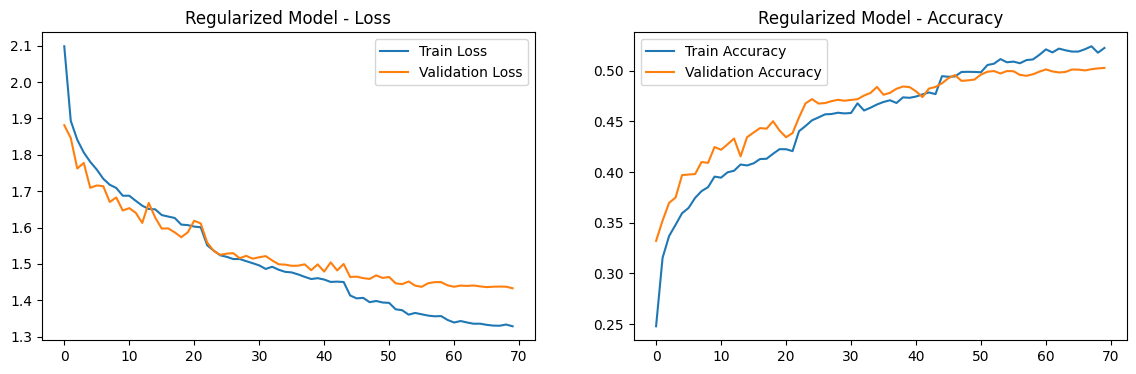

In [5]:
from tensorflow.keras import regularizers

model_regularized = keras.Sequential([

    layers.Input(shape=(3072,)),
    layers.Dense(2048, activation='relu',kernel_regularizer=regularizers.l2(1e-5)),
    layers.Dropout(0.3),
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

model_regularized.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=8,
    restore_best_weights=False
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

checkpoint = callbacks.ModelCheckpoint(
    'best_cifar10_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

history_regularized = model_regularized.fit(
    X_train,
    y_train,
    epochs=70,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

plot_history(history_regularized, "Regularized Model")


### Шаг 5: Оценка результата
1. Загрузите лучшие веса из сохраненного файла (`keras.models.load_model`).
2. Сделайте `.predict()` на тестовой выборке (`X_test`).
3. Выведите итоговое значение `accuracy_score`. Смогли ли вы преодолеть барьер в 50%?
4. Напишите краткий вывод: какой инструмент по вашему мнению оказал наибольшее влияние на результат?

In [8]:
best_model = keras.models.load_model("best_cifar10_model.keras")

probabilities = best_model.predict(X_test, verbose=0)
y_pred = np.argmax(probabilities, axis=1)
y_true = np.argmax(y_test, axis=1)

final_accuracy = accuracy_score(y_true, y_pred)
correct = np.sum(y_pred == y_true)
wrong = len(y_true) - correct

print("Accuracy:", final_accuracy)
print("Цель 50% достигнута:", final_accuracy >= 0.5)

Accuracy: 0.5007
Цель 50% достигнута: True


Наибольшее влияние на результат оказал Dropout. Он случайно отключает часть нейронов во время обучения и не дает модели слишком сильно запоминать обучающую выборку. Благодаря этому уменьшилось переобучение и улучшилось качество на тестовых данных.